**From a series of application of modern interpolation methods for economics: written by [Mahdi E Kahou] (https://mekahou.github.io/)**

# Goal of this notebook

This notebook introduces **spectral bias** (also called the **frequency principle**) and uses it to explain a fact I relied on in my work:

> **Neural networks learn low frequencies first, and resist high-frequency oscillation.**

The goal is twofold:

1. To show that when a function is built from several frequencies, a neural network does not learn them all at once. It captures the slow, low-frequency structure first, and fills in the fast oscillations later, if at all.
2. To connect this ordering to why neural networks tend to produce smooth solutions, in contrast to classical families that oscillate.

---

## General setup

Let $k : [0, 8\pi] \to \mathbb{R}$ be a sum of sinusoids that mixes one slow mode with progressively faster ones,

$$
k(x) = \tfrac{1}{4}\left(\sin x + \sin 5x + \sin 10x + \sin 20x\right).
$$

We fit $k$ on a dense grid with a small tanh network. The spread of frequencies lets us watch the stages cleanly: the slow mode is captured first, and the fast oscillations arrive much later, if at all.

---

## Spectral bias

The empirical observation, documented for ReLU networks by Rahaman et al. (2019) and for tanh networks by Xu et al. (2020), is that gradient-based training fits the low-frequency content of the target early and the high-frequency content late. The high frequencies need finely tuned parameters, so they are reached last. 

## The target function

In [1]:
## Importing packages
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
## Multi-frequency dgp on [0, 8 pi]
X_min, X_max = 0.0, 8 * np.pi

def dgp(x):
    return (np.sin(x) + np.sin(5 * x) + np.sin(10 * x) + np.sin(20 * x)) / 4.0

def normalize(x):
    # map [X_min, X_max] -> [-1, 1] before feeding the network
    return 2.0 * (x - X_min) / (X_max - X_min) - 1.0

In [3]:
## Training data (fixed uniform grid)
n_train = 1000
x_train_np = np.linspace(X_min, X_max, n_train)
y_train_np = dgp(x_train_np)

In [4]:
## Test data (dense grid for plotting / FFT)
n_eval = 8192
x_test_np = np.linspace(X_min, X_max, n_eval)
y_true_np = dgp(x_test_np)

In [5]:
fontsize= 14
ticksize = 14
figsize = (8, 6)
params_fig = {'font.family':'serif',
    "figure.figsize":figsize,
    'figure.dpi': 80,
    'figure.edgecolor': 'k',
    'font.size': fontsize,
    'axes.labelsize': fontsize,
    'axes.titlesize': fontsize,
    'xtick.labelsize': ticksize,
    'ytick.labelsize': ticksize
}
plt.rcParams.update(params_fig)

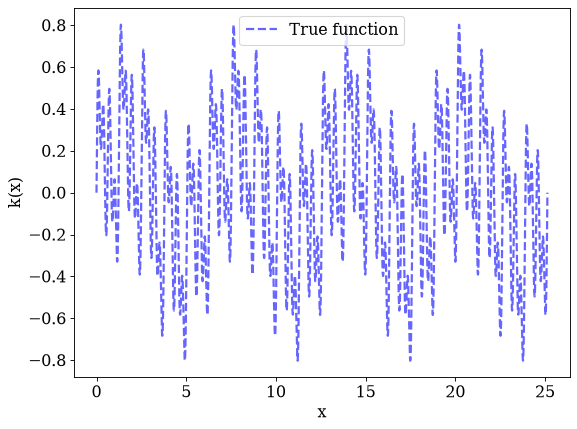

In [6]:
plt.plot(x_test_np, y_true_np, label="True function", color ="b", linestyle="--" , linewidth=2, alpha = 0.6)
plt.xlabel("x")
plt.ylabel("k(x)")
plt.legend(loc = "upper center")

## Deep Learning Implementation

#### Defining the neural network

In [7]:
class NN(nn.Module):
    def __init__(self,
                 input_dim = 1,
                 dim_hidden=128,
                 layers=3,
                 hidden_bias=True,
                 hidden_activation=nn.Tanh,
                 seed=123):
        super().__init__()
        self.input_dim = input_dim
        self.dim_hidden = dim_hidden
        self.layers = layers
        self.hidden_bias = hidden_bias
        self.hidden_activation = hidden_activation
        self.seed = seed

        # Set seed if provided
        if self.seed is not None:
            torch.manual_seed(self.seed)
        
        module = []
        
        # First layer
        module.append(nn.Linear(self.input_dim, self.dim_hidden, bias=self.hidden_bias))
        module.append(self.hidden_activation())

        # Additional hidden layers
        for _ in range(self.layers - 1):
            module.append(nn.Linear(self.dim_hidden, self.dim_hidden, bias=self.hidden_bias))
            module.append(self.hidden_activation())

        module.append(nn.Linear(self.dim_hidden, 1))

        self.q = nn.Sequential(*module)

    def forward(self, x):
        return self.q(x)

#### Training data and data loader

In [8]:
# the network sees the normalized input, the target is unchanged
x_train = torch.from_numpy(normalize(x_train_np)).float().unsqueeze(dim = 1)
y_train = torch.from_numpy(y_train_np).float().unsqueeze(dim = 1)

train_dataset = TensorDataset(x_train, y_train)
batch_size = len(x_train)
# Create dataloader
train_loader = DataLoader(train_dataset, batch_size= batch_size, shuffle = False)

In [9]:
num_epochs = 20001
print_freq = 1000

#### Initializing the neural network

In [10]:
 # 3 hidden layers of 64, tanh

model = NN(dim_hidden=64, layers=3) 

### Setting the optimizer

In [11]:
optimizer = optim.Adam(model.parameters(), lr = 2e-3)


#### Mean-squared loss function

In [12]:
criterion = nn.MSELoss()

#### Training loop

In [13]:
for epoch in range(num_epochs):
    for x,y in train_loader:
        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()
        
    if (epoch) % print_freq == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.8f}')

Epoch [1/20001], Loss: 0.12598500
Epoch [1001/20001], Loss: 0.09202334
Epoch [2001/20001], Loss: 0.09267946
Epoch [3001/20001], Loss: 0.09151067
Epoch [4001/20001], Loss: 0.09079945
Epoch [5001/20001], Loss: 0.08581323
Epoch [6001/20001], Loss: 0.08344195
Epoch [7001/20001], Loss: 0.07811871
Epoch [8001/20001], Loss: 0.07730191
Epoch [9001/20001], Loss: 0.06900820
Epoch [10001/20001], Loss: 0.06295371
Epoch [11001/20001], Loss: 0.05803661
Epoch [12001/20001], Loss: 0.05143681
Epoch [13001/20001], Loss: 0.04767866
Epoch [14001/20001], Loss: 0.04398099
Epoch [15001/20001], Loss: 0.03862946
Epoch [16001/20001], Loss: 0.03478941
Epoch [17001/20001], Loss: 0.03199327
Epoch [18001/20001], Loss: 0.02798664
Epoch [19001/20001], Loss: 0.02469841
Epoch [20001/20001], Loss: 0.02392334


In [14]:
x_test = torch.from_numpy(normalize(x_test_np)).float().unsqueeze(dim = 1)

In [15]:
model.eval()
with torch.no_grad():
    y_test_DL = model(x_test)

#### The fit and its frequency content

To see the ordering directly, we compare the discrete Fourier transform of the network output with that of the target. Because $k$ is real, its spectrum is symmetric, so we show only $\omega \ge 0$, on the angular-frequency axis. The target has four spectral lines, at $\omega = 1, 5, 10, 20$.

In [16]:
## Fourier transform (real signal -> one-sided, angular frequency)
dx = x_test_np[1] - x_test_np[0]
omega = 2 * np.pi * np.fft.fftshift(np.fft.fftfreq(n_eval, d=dx))  # angular
pos = omega >= 0                           # real signal: one-sided spectrum
omega = omega[pos]

def spectrum(u_vals):
    Fu = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(u_vals))) * dx
    return np.abs(Fu)[pos]

y_dl_np = y_test_DL.squeeze().numpy()
ft_true = spectrum(y_true_np)
ft_dl = spectrum(y_dl_np)

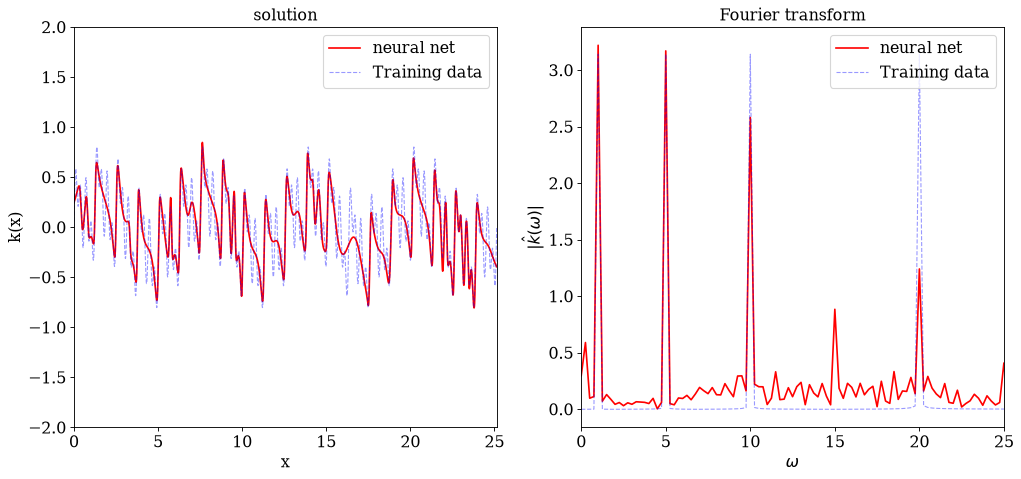

In [18]:
fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 6.5))

axL.plot(x_test_np, y_dl_np, color="red", lw=1.5, label="neural net")
axL.plot(x_test_np, y_true_np, color="blue", lw=1.0, ls="--", alpha=0.4, label="Training data")
axL.set_xlim(X_min, X_max)
axL.set_ylim(-2.0, 2.0)
axL.set_xlabel("x")
axL.set_ylabel("k(x)")
axL.set_title("solution")
axL.legend(loc="upper right")

axR.plot(omega, ft_dl, color="red", lw=1.5, label="neural net")
axR.plot(omega, ft_true, color="blue", lw=1.0, ls="--", alpha=0.4, label="Training data")
axR.set_xlim(0, 25)
axR.set_xlabel(r"$\omega$")
axR.set_ylabel(r"$|\hat{k}(\omega)|$")
axR.set_title("Fourier transform")
axR.legend(loc="upper right")

plt.show()